### Simpson rule with NumPy capabilities

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma # Gamma function for the real value

In [2]:
def simpson(f, a, b, N): # Simpson function
 
    if N <= 0 or N % 2 != 0: raise ValueError("N must be a positive even integer for Simpson's 1/3 rule.") # N must be even

    x = np.linspace(a, b, N + 1)
    y = f(x)

    h = (b - a) / N

    return h / 3.0 * ( # Integral result
        y[0] + y[- 1]
        + 4.0 * np.sum(y[1: - 1: 2])
        + 2.0 * np.sum(y[2: - 1: 2])
    )

def trap(f, a, b, N): # Trapezoidal rule just for comparison

    x = np.linspace(a, b, N + 1)
    y = f(x)
    h = (b - a) / N

    return h * (0.5 * y[0] + np.sum(y[1:- 1]) + 0.5 * y[- 1])

In [3]:
a, b = - 4.0, 4.0
N_max = 40
N = np.arange(2, N_max + 2, 2) # 2, 4, 6, ..., N_max
f = lambda x: np.exp(- x ** 4) # e^(- x ^ 4)

I_simps = np.array( # Array of integrals using Simpson rule
    [simpson(
        f = f,
        a = a,
        b = b,
        N = N_v
) for N_v in N]
)

I_trape = np.array( # Array of integrals using trapezoidal rule
    [trap(
        f = f,
        a = a,
        b = b,
        N = N_v
) for N_v in N]
)

I_simps, I_trape

(array([5.33333333, 1.33333393, 1.85316408, 1.64767866, 1.77788343,
        1.94125746, 1.72361153, 1.83957674, 1.82252288, 1.79533623,
        1.82301847, 1.81123123, 1.81046601, 1.8149251 , 1.81217295,
        1.81253248, 1.81316299, 1.8126814 , 1.81276738, 1.81286045]),
 array([4.        , 2.00000045, 1.44641279, 1.73575911, 1.86454518,
        1.81754629, 1.80644733, 1.81362233, 1.81317561, 1.81263847,
        1.81282589, 1.81280999, 1.81280196, 1.81280566, 1.81280488,
        1.81280494, 1.81280496, 1.81280495, 1.81280495, 1.81280495]))

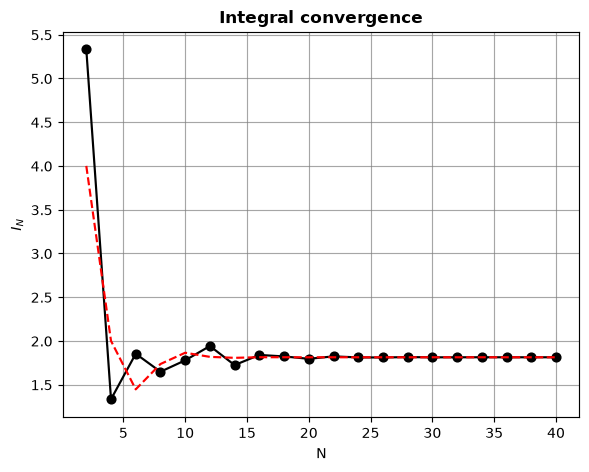

In [4]:
# Plotting results
plt.title("Integral convergence", fontweight = "bold")
plt.plot(N, I_simps, 'o-', color = "black")
plt.plot(N, I_trape, '--', color = "red")
plt.xlabel("N")
plt.ylabel(r"$I_N$")
plt.grid("--", color = "gray", alpha = 0.7)
plt.show()

Let's write an adaptive algorithm. By Richardson method, the estimated absolute error between $I_{2N}$ and $I_N$ is just $\left| I_{2N} - I_N \right| / 15$

In [5]:
def adaptive_simpson(f, a, b, N_0, tol): # Adaptive version

    N = N_0

    while True:

        I_1 = simpson(f, a, b, N) # N subdivisions
        I_2 = simpson(f, a, b, 2 * N) # 2N subdivisions

        err = np.abs(I_2 - I_1) / 15.0 # Richardson formula
        rel_err = err / np.abs(I_2)

        if rel_err < tol: # When the relative error is under the tolerance value
            return I_2, err, rel_err, 2 * N # Integral value, absolute error estimated, relative error estimated, number of subdivisions

        N *= 2

In [6]:
adaptive_simpson( # Machine precision result
    f = f,
    a = a,
    b = b,
    N_0 = 2,
    tol = 1e-09
)

(np.float64(1.812804954110954),
 np.float64(2.406756275756076e-10),
 np.float64(1.3276421549368564e-10),
 128)

In [7]:
0.5 * gamma(0.25) # Real value

np.float64(1.812804954110954)